In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json

print("All imports successful!")

All imports successful!


In [3]:
DATA_DIR = Path("/Users/hnq/Desktop/licenta/cod_plante/data")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

SRC_DIR = Path("/Users/hnq/Desktop/licenta/cod_plante/src")
SRC_DIR.mkdir(exist_ok=True)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Train folder exists: {TRAIN_DIR.exists()}")
print(f"Val folder exists: {VAL_DIR.exists()}")

Using device: mps
Train folder exists: True
Val folder exists: True


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Training transforms defined")
print(train_transforms)

Training transforms defined
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Validation transforms defined")
print(val_transforms)

Validation transforms defined
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [6]:
train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=VAL_DIR,
    transform=val_transforms
)

print(f"Training dataset: {len(train_dataset)} images")
print(f"Validation dataset: {len(val_dataset)} images")
print(f"Number of classes: {len(train_dataset.classes)}")

Training dataset: 43444 images
Validation dataset: 10861 images
Number of classes: 38


In [7]:
class_names = train_dataset.classes

classes_path = SRC_DIR / "classes.json"
with open(classes_path, "w") as f:
    json.dump(class_names, f, indent=2)

print(f"Saved {len(class_names)} class names to {classes_path}")

Saved 38 class names to /Users/hnq/Desktop/licenta/cod_plante/src/classes.json


In [10]:
BATCH_SIZE = 32
NUM_WORKERS = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Batch size: {BATCH_SIZE}")

Train batches: 1358
Val batches: 340
Batch size: 32


In [11]:
images, labels = next(iter(train_loader))

print(f"Batch shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Image data type: {images.dtype}")
print(f"Image value range: [{images.min():.3f}, {images.max():.3f}]")
print(f"Sample labels: {labels[:10].tolist()}")

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Image data type: torch.float32
Image value range: [-2.118, 2.640]
Sample labels: [15, 15, 11, 28, 0, 5, 5, 37, 29, 30]


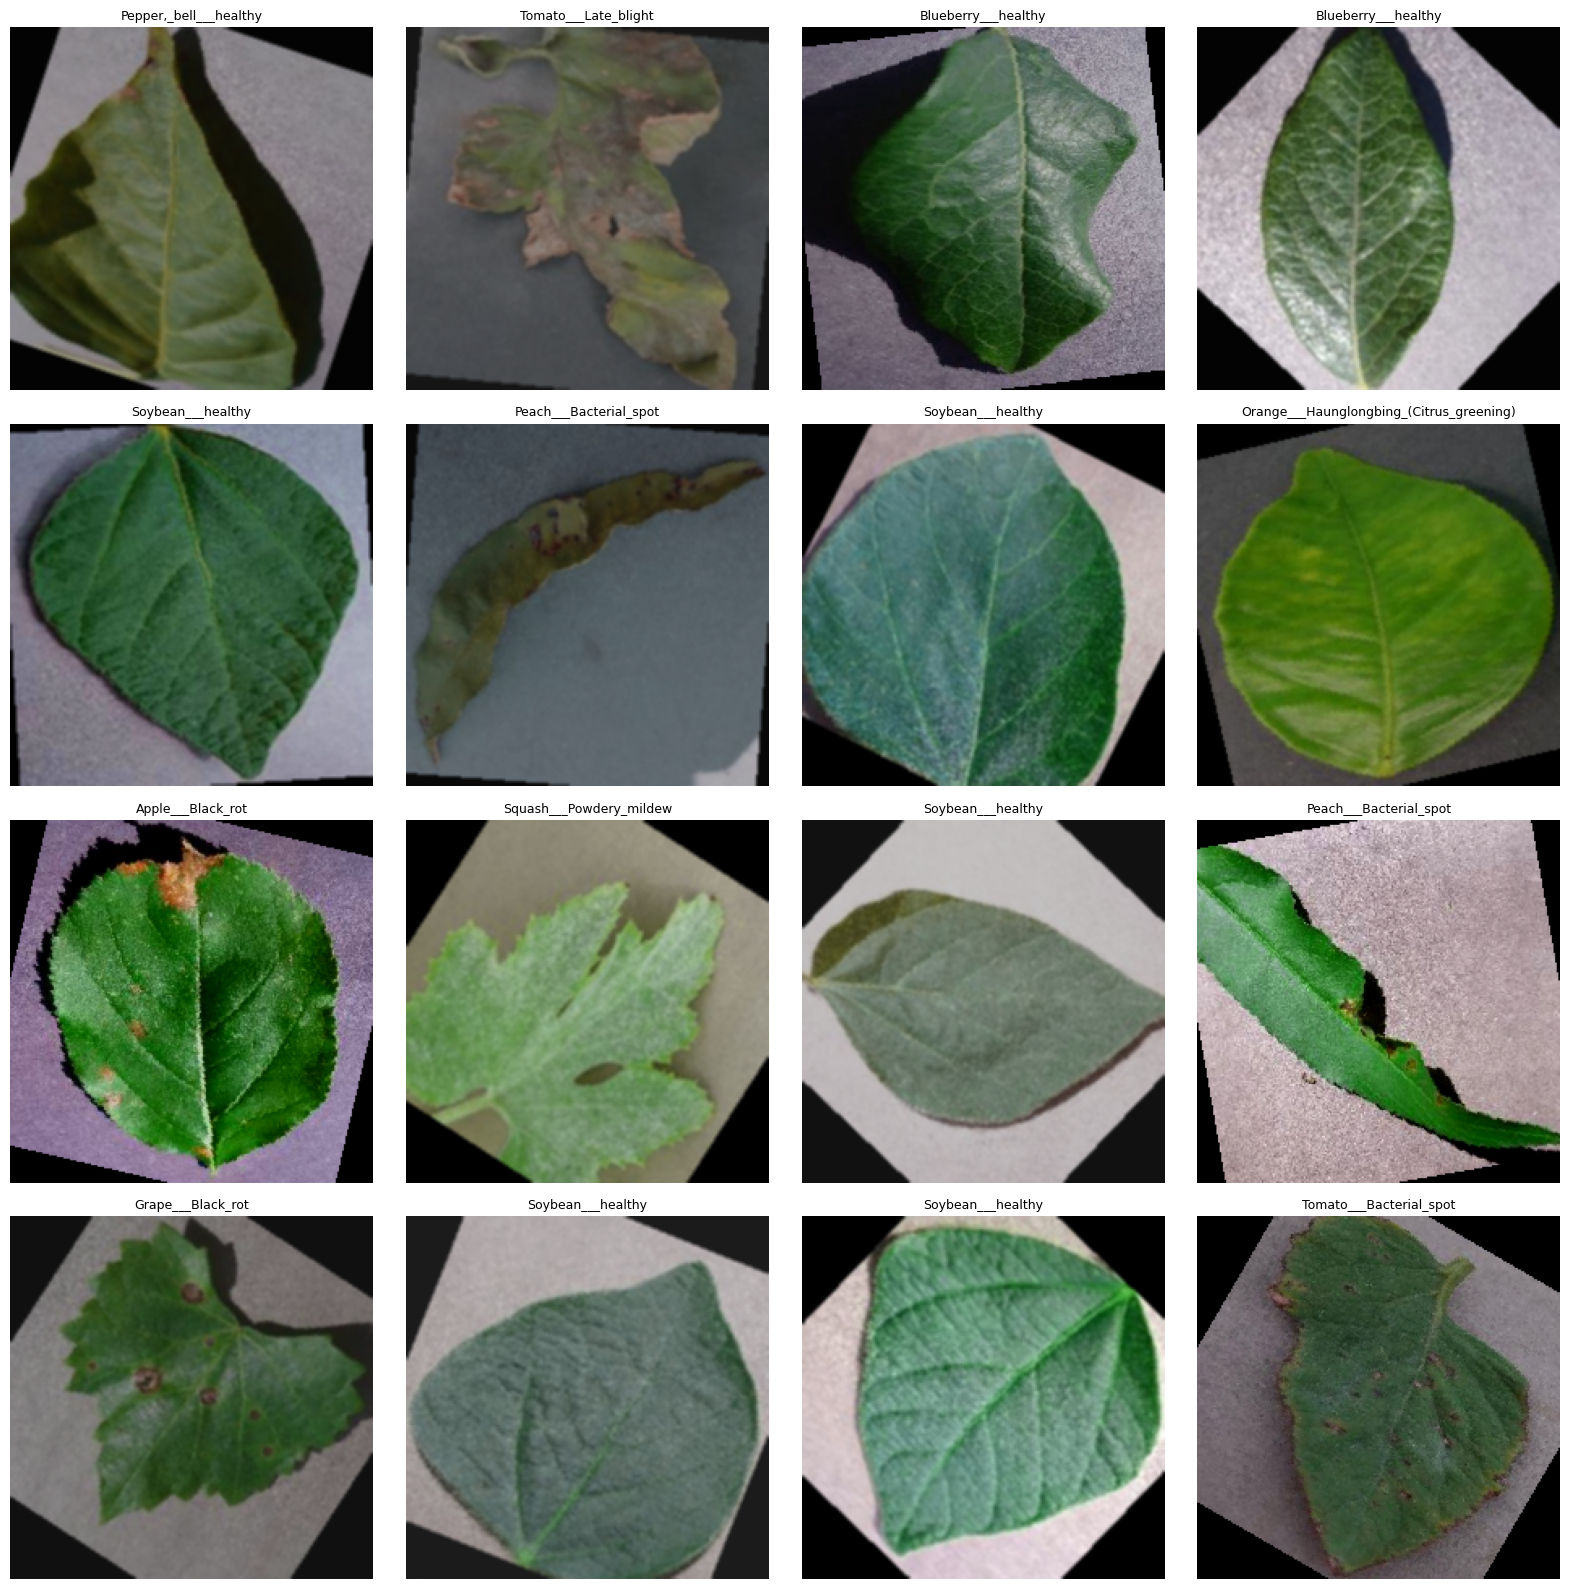

Augmented batch saved to n02_augmented_batch.png


In [12]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return tensor * std + mean

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx in range(16):
    img = denormalize(images[idx])
    img = img.permute(1, 2, 0)
    img = img.clamp(0, 1)
    
    axes[idx].imshow(img.numpy())
    axes[idx].set_title(class_names[labels[idx]], fontsize=9)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('n02_augmented_batch.png', dpi=100, bbox_inches='tight')
plt.show()

print("Augmented batch saved to n02_augmented_batch.png")